# PRE-S3 PREVIEW — cbg-park-seasonal with refactored BSTPP

> **Exploratory early-testing notebook.** Results produced here must be regenerated at the official S3 analysis-resumption checkpoint. This copy leaves the historical notebook unchanged.

Every migration change is marked `PRE-S3 MIGRATION EDIT`. The preview preserves the historical unweighted standardization over all 1,338 supplied CBG rows, uses a fixed 1,000 m per-axis spatial computational cutoff, and treats the real-unit spatial prior as a sensitivity choice (50, 100, or 250 m; provisional default 250 m).


In [4]:
## PRE-S3 MIGRATION EDIT: package from BSTPP preview; this notebook lives in Illegal-Dumping
import os
import sys
from pathlib import Path

# BSTPP package: yuxinlg/BSTPP-for-illegal-dumping branch `preview`
# Park analysis files: this repo, replication/ (Illegal-Dumping branch `preview/parks`)
PREVIEW_ROOT = Path(os.environ.get('BSTPP_PREVIEW_ROOT', r'C:\Users\Terhi\dev\BSTPP_preview')).resolve()
ANALYSIS_ROOT = Path(os.environ.get('BSTPP_ANALYSIS_ROOT', r'C:\Users\Terhi\dev\BSTPP_analysis')).resolve()
if not (PREVIEW_ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('BSTPP_PREVIEW_ROOT must identify the BSTPP preview checkout')
sys.path.insert(0, str(PREVIEW_ROOT))
sys.path.insert(0, str(ANALYSIS_ROOT / 'replication'))  # batch_park_fits
os.chdir(ANALYSIS_ROOT)  # historical data/ and output/ paths remain valid
REPO = str(ANALYSIS_ROOT / 'replication')
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)
print("Preview repo:", PREVIEW_ROOT)
print("Analysis root:", ANALYSIS_ROOT)

import bstpp
print("BSTPP path:", bstpp.__file__)

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import box
#!pip install contextily
import contextily as ctx ## for basemap
#!pip install matplotlib-scalebar
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import shapely.geometry as geom
from scipy.stats import lomax
from collections import defaultdict
from statistics import mean, median
# from tqdm import tqdm
from tqdm.notebook import tqdm



np.random.seed(999)


from bstpp.main import Hawkes_Model
from bstpp.trigger import Temporal_Power_Law, simulate_hawkes_like_events,plot_inter_arrival_distribution

JAX path: c:\Users\Terhi\miniconda3\envs\illegal-dumping\Lib\site-packages\jax\__init__.py
Preview repo: C:\Users\Terhi\dev\BSTPP_preview
Analysis root: C:\Users\Terhi\dev\BSTPP_analysis
BSTPP path: C:\Users\Terhi\dev\BSTPP_preview\bstpp\__init__.py


In [5]:
## working directory (set by setup_project in cell above)
import os
print("cwd:", os.getcwd())

cwd: C:\Users\Terhi\dev\BSTPP_analysis


## Loadding shapefiles for plotting

### CBG border and Land care data

In [6]:
# load philly cbg border
pa_2023 = gpd.read_file('data/tl_2023_42_bg.shp')
philly_2023 = pa_2023[pa_2023['COUNTYFP']=='101']
philly_2023 = philly_2023.to_crs(epsg=26918)

In [7]:
## load land care data
land_care = gpd.read_file('data/phs_landcare.geojson')

land_care['year'] = pd.to_numeric(land_care['year'], errors='coerce')

## Filter for years between 2021 and 2025
land_care_21_25= land_care[(land_care['year'] >= 2021) & (land_care['year'] <= 2025)]

land_care_21_25 = land_care_21_25.to_crs(epsg=26918)

### Land Use

In [9]:
# ## load land use data
# land_use_current = gpd.read_file('data/Land_use.geojson')

# ## recategorize land use types
# land_use_current['type'] = pd.Series(dtype='object')

# # residential
# land_use_current.loc[(land_use_current['c_dig2'] == 11),'type'] = "Res Low Den"
# land_use_current.loc[(land_use_current['c_dig2'] == 12),'type'] = "Res Med Den"
# land_use_current.loc[(land_use_current['c_dig2'] == 13),'type'] = "Res High Den"
# # commercial
# land_use_current.loc[
#     (land_use_current['c_dig2'] == 21) | (land_use_current['c_dig2'] == 22)|(land_use_current['c_dig2'] == 23),
#     'type'
# ] = "Commercial"
# # civic 
# land_use_current.loc[
#     (land_use_current['c_dig2'] == 41) | (land_use_current['c_dig2'] == 61)|(land_use_current['c_dig2'] == 62)|(land_use_current['c_dig2'] == 71)|(land_use_current['c_dig2'] == 72),
#     'type'
# ] = "Civic"
# # other
# land_use_current.loc[(land_use_current['c_dig2'] == 31),'type'] = "Industry"
# land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Transportation"
# land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Green ROW"
# land_use_current.loc[(land_use_current['c_dig2'] == 81),'type'] = "Water"
# land_use_current.loc[(land_use_current['c_dig2'] == 91),'type'] = "Vacant"
# land_use_current.loc[(land_use_current['c_dig2'] == 92),'type'] = "Other"

In [11]:
# ## Customize color map for land use categories
# use_lst = ['Res Low Den', 'Res Med Den', 'Res High Den', 'Commercial', 'Civic', 'Industry', 'Transportation', 'Green ROW', 'Water', 'Vacant', 'Other']
# colors = ['#543f32', '#db4d6d', '#69821b', '#e6b422', '#5654a2','#0095d9', '#a73836', '#a8bf93','#164a84', '#b3ada0','#d3cfd9']

# use_color = dict(zip(colors,use_lst))

# ## reset order in land_use_currect
# land_use_current['type'] = pd.Categorical(land_use_current['type'], categories=use_lst, ordered=True)

# land_use_current = land_use_current.to_crs(epsg=26918)

In [ ]:
# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# fig, ax = plt.subplots(figsize=(9,9))
# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.9,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )
# plt.title('Land Use Types')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/land_use.png', dpi=500, bbox_inches='tight')
# plt.show()

### Vacant Block

In [13]:
# ## load data
# vacant_block = gpd.read_file('data/Vacant_Block_Percent_Land.geojson')
# vacant_block = vacant_block.to_crs(epsg=26918)

## Loadding illegal dumping data

### Public-accessible 311: 2014 till now

In [ ]:
# ## load 2024 data
# litter_24 = gpd.read_file('data/311/2024/public_cases_fc.shp')
# ## filter data
# illegal_dumping_24 = litter_24[litter_24['service_na'] == "Illegal Dumping"]

# ## load 2023 data
# litter_23 = gpd.read_file('data/311/2023/public_cases_fc.shp')
# ## filter data
# illegal_dumping_23 = litter_23[litter_23['service_na'] == "Illegal Dumping"]

# ## load 2022 data
# litter_22 = gpd.read_file('data/311/2022/public_cases_fc.shp')
# ## filter data
# illegal_dumping_22 = litter_22[litter_22['service_na'] == "Illegal Dumping"]

# ## load 2021 data
# litter_21 = gpd.read_file('data/311/2021/public_cases_fc.shp')
# ## filter data
# illegal_dumping_21 = litter_21[litter_21['service_na'] == "Illegal Dumping"]

# ## load 2020 data: skip since COVID
# #litter_20 = gpd.read_file('data/311/2020/public_cases_fc.shp')
# ## filter data
# #illegal_dumping_20 = litter_20[litter_20['service_na'] == "Illegal Dumping"]

In [ ]:
# ## concact 2021, 2022, 2023, and 2024 data
# illegal_dumping = pd.concat([
#     #illegal_dumping_20,
#     illegal_dumping_21,
#     illegal_dumping_22,
#     illegal_dumping_23,
#     illegal_dumping_24
# ])
# #illegal_dumping = illegal_dumping_23
# total_days = 365 * 4

# illegal_dumping = illegal_dumping.to_crs(epsg=26918)

In [ ]:
## export to geojson
#illegal_dumping.to_file('output/illegal_dumping_21_24.geojson', driver='GeoJSON')

### 311 Data from the teams

In [14]:
## PRE-S3 MIGRATION EDIT: load a fixed four-calendar-year interval
illegal_dumping = gpd.read_file('output/illegal_dumping_full.geojson')
illegal_dumping['start_time'] = pd.to_datetime(illegal_dumping['start_time'])

ANALYSIS_START = pd.Timestamp('2021-01-01')
ANALYSIS_END = pd.Timestamp('2025-01-01')
illegal_dumping = illegal_dumping[
    (illegal_dumping['start_time'] >= ANALYSIS_START)
    & (illegal_dumping['start_time'] < ANALYSIS_END)
].copy()

# Includes the 2024 leap day: 1,461 days, not 365 * 4.
total_days = int((ANALYSIS_END - ANALYSIS_START).days)

print(illegal_dumping.shape[0])

109815


In [15]:
illegal_dumping['department'].unique()

array(['Streets Department', 'Philly311 Contact Center',
       'Parks & Recreation'], dtype=object)

In [16]:
illegal_dumping[illegal_dumping['department']=="Parks & Recreation"].head()

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,material_type,material_condition,description,lat,lon,case_id,parent_case_id,media_url,year,geometry
127231,2021-03-29 09:31:00,2021-03-30 16:26:00,14027719,Grounds Maintenance,Parks & Recreation,1401 N 5TH ST,19122.0,Closed,Grounds,None,...,None,None,undefined\n\n Custom Fields: \nCustom fields:\...,39.972969,-75.144099,5001M00001gjEXH,None,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (487694.893 4424766.968)
127232,2021-09-06 09:03:00,2022-01-14 13:31:00,14395035,Grounds Maintenance,Parks & Recreation,3910 CONSHOHOCKEN AVE,19131.0,Closed,Grounds,None,...,None,None,Bagged trash needs to be picked up.\n\n Custom...,40.001963,-75.208395,5001M00001lHYLi,None,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (482211.993 4427995.854)
127233,2021-04-05 17:46:00,NaT,14051731,Grounds Maintenance,Parks & Recreation,600 W SPENCER AVE,19120.0,In-Progress,Grounds,Landscape,...,None,None,Custom Fields: \nCustom fields:\nLarge Crew & ...,40.044339,-75.130841,5001M00001hEzMC,None,None,2021.0,POINT (488838.677 4432686.588)
127234,2021-03-01 10:52:00,2021-05-05 17:15:00,13961203,Grounds Maintenance,Parks & Recreation,3001 E THOMPSON ST,19134.0,Closed,Grounds,None,...,None,None,"Overflowing trash cans, shredded flag, shoppin...",39.982371,-75.107108,5001M00001g2dSP,None,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (490854.925 4425806.023)
127235,2021-03-28 17:19:00,2021-04-29 08:09:00,14027141,Grounds Maintenance,Parks & Recreation,3001 E ALLEGHENY AVE,19134.0,Closed,Grounds,None,...,None,None,Trash is overflowing and graffiti on boat more...,39.977998,-75.095177,5001M00001gj881,5001M00001hDE17,https://d17aqltn7cihbm.cloudfront.net/uploads/...,2021.0,POINT (491873.138 4425319.498)


In [17]:
## break down material type
# Split the categories and create a list of all categories
all_categories = illegal_dumping['material_type'].str.split(';').explode().str.strip()

# Find the unique values
unique_categories = all_categories.unique()

# Print the unique categories
print(unique_categories)

['Other' 'Mattress and Furniture' 'Mattress/Furniture'
 'Construction Material' 'Construction Materials' 'Appliances'
 "TV's and Monitors" 'TV?s and Monitors' None 'Mattress & Furniture'
 'Tires' 'Building Materials']


### 311 Data - first case within clusters

In [ ]:
# # ## loadding filtered 311 data
# illegal_dumping = gpd.read_file('output/illegal_dumping_clustered.geojson')

# ## filter out cases after 2024-12-31
# #illegal_dumping = illegal_dumping[illegal_dumping['start_time'] <= '2025-01-01']

# ## set total days
# total_days = 365 * 4

## Loadding shapefiles

### Get University City's polygon

In [18]:
## downloaded from https://github.com/opendataphilly/open-geo-data/tree/master/philadelphia-neighborhoods
philly_neighbor = gpd.read_file('data/philadelphia-neighborhoods.geojson')
philly_neighbor = philly_neighbor.to_crs(26918)

## restrict to University City
univ_city = philly_neighbor[philly_neighbor['MAPNAME'] == 'University City']

In [19]:
## set buffer square
buffer_val = 300  # meters
minx, miny, maxx, maxy = univ_city.total_bounds
univ_square = geom.box(minx - buffer_val, miny - buffer_val,
                              maxx + buffer_val, maxy + buffer_val)

# Wrap into GeoDataFrame for plotting/export
univ_square_gdf = gpd.GeoDataFrame(geometry=[univ_square], crs=univ_city.crs)

In [20]:
## export to geojson
univ_square_gdf.to_file('output/univ_square_gdf.geojson', driver='GeoJSON')


In [ ]:
# fig,ax = plt.subplots()
# univ_city.plot(ax=ax)
# univ_square_gdf.plot(ax= ax, edgecolor = "blue", color = "none")

In [ ]:
# ## check if univ_city is all-covered by foot traffic data
# # load foor traffic data
# df_avg_geo = gpd.read_file('output/ft_avg_geo.geojson')

# ft_univ = df_avg_geo.sjoin(univ_square_gdf, predicate='intersects')

In [ ]:
# ## plotting to check
# fig,ax = plt.subplots()
# univ_city.plot(ax=ax, edgecolor = "#011f5b", color = "none", linewidth=2, zorder=3)
# univ_square_gdf.plot(ax=ax, edgecolor = "blue", color = "none")
# ft_univ.plot(ax=ax, edgecolor = "red", color = "white", alpha = 0.5)

### Loadding park boundaries

In [21]:
## load philly's cphilly_bity map for mapping
philly_border = gpd.read_file('data/City_Limits.shp')
philly_border = philly_border.to_crs(epsg=26918)

# ## load PPR data
# ppr =gpd.read_file('parks/PPR/PPR_Properties.geojson')
# ppr = ppr.to_crs(26918)

# ## get Cobbs Creek's map
# cobbscreek = ppr[ppr["OBJECTID"].isin([432])]

# ## get Mifflin Square's map
# mifflin = ppr[ppr["OBJECTID"].isin([208])]

# ## Tacony
# tacony = ppr[ppr["OBJECTID"].isin([10, 64])]

# ## Fairmount
# fairmount = ppr[ppr["OBJECTID"].isin([7, 9])]

#### Setting boxes around parks

In [ ]:
# ## list of parks
# parks = {
#     'cobbscreek': cobbscreek,
#     'mifflin': mifflin,
#     'tacony': tacony,
#     'fairmount': fairmount
# }

# # set buffer value
# buffer = 300 # meters

# # collect results
# all_parks_gdf = gpd.GeoDataFrame() # for plotting
# all_boxes_gdf = gpd.GeoDataFrame() # for filtering

# # loop: get boxes around 
# for name, gdf in parks.items():
#     # skip empty GeoDataFrames
#     if gdf.empty:
#         continue
    
#     # store parks geometries
#     all_parks_gdf = pd.concat([all_parks_gdf, gdf], ignore_index=True)

#     # compute total bounds
#     minx, miny, maxx, maxy = gdf.total_bounds
#     minx -= buffer
#     maxx += buffer
#     miny -= buffer
#     maxy += buffer

#     # compute the side length of the square
#     side = max(maxx - minx, maxy - miny)
#     center_x = (minx + maxx) / 2
#     center_y = (miny + maxy) / 2

#     # create square box
#     square_minx = center_x - side / 2
#     square_maxx = center_x + side / 2
#     square_miny = center_y - side / 2
#     square_maxy = center_y + side / 2
#     square_geom = box(square_minx, square_miny, square_maxx, square_maxy)

#     # create GeoDataFrame for box
#     square_gdf = gpd.GeoDataFrame(
#         {'PARKNAME': [f"{name}_box"]},
#         geometry=[square_geom],
#         crs=gdf.crs
#     )

#     # add box to collection
#     all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf], ignore_index=True)

In [ ]:
## export geoJSON
#all_parks_gdf.to_file("output/all_parks_gdf.geojson", driver="GeoJSON")
#all_boxes_gdf.to_file("output/all_boxes_gdf.geojson", driver="GeoJSON")

In [24]:
# NEW ADDITION: ACCESS PARK BOUNDARIES ALREADY SAVED

all_parks_gdf = gpd.read_file("output/all_parks_gdf.geojson").to_crs(epsg=26918)
all_boxes_gdf = gpd.read_file("output/all_boxes_gdf.geojson").to_crs(epsg=26918)
print(all_boxes_gdf["PARKNAME"].tolist())

['cobbscreek_box', 'mifflin_box', 'tacony_box', 'fairmount_box', 'fairmount_aoi_box', 'cobbs_aoi_box', 'cobbs_aoi_focus']


## Loadding cbg-level cov dataset

In [25]:
## load covariates
cov_gdf = gpd.read_file('output/cov_cbg.geojson')
cov_gdf = cov_gdf.to_crs(epsg=26918)

In [26]:
cov_gdf.columns

Index(['state', 'county', 'tract', 'block group', 'GEOID', 'pop_density',
       'med_inc_avg', 'lep_density', 'edu_hs_avg', 'vac_area', 'ndvi_mean_4yr',
       'RLD', 'RMD', 'RHD', 'CC', 'CBP', 'CMR', 'I', 'Civic', 'T', 'GW',
       'Cult', 'AR', 'Park', 'Cemetery', 'Water', 'VL', 'Other', 'use_res',
       'use_com', 'use_civ', 'landcare_area', 'area_B', 'alloc_avg_d_cnt',
       'alloc_avg_s_cnt', 'unique_device_ratio_aw', 'reporting_rate',
       'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d',
       'pagerank_avg_d', 'geometry'],
      dtype='object')

### Plotting

In [ ]:
# fig, ax = plt.subplots(figsize=(9,9))
# cov_gdf.plot(ax=ax, column='pop_density', cmap='viridis', alpha = 0.9,legend=True, legend_kwds={'shrink': 0.9})
# all_parks_gdf.plot(ax=ax, edgecolor='#cc7eb1', facecolor='none', linewidth=1,alpha=0.9)
# plt.title('Population Density (people/km^2)')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/pop_density.png', dpi=500, bbox_inches='tight')
# plt.show()


In [ ]:
# fig, ax = plt.subplots(figsize=(9,9))
# cov_gdf.plot(ax=ax, column='litter_rating_avg', cmap='BuPu', alpha = 0.9,legend=True, legend_kwds={'shrink': 0.9})
# all_parks_gdf.plot(ax=ax, edgecolor='white', facecolor='none', linewidth=1,alpha=0.9)
# plt.title('Litter Rating')
# plt.xticks([])
# plt.yticks([])
# ax.set_frame_on(False)
# plt.savefig('output/litter_rating.png', dpi=500, bbox_inches='tight')
# plt.show()

### Filtering points in Univ City

In [ ]:
# # First join: illegal dumping within all_boxes_gdf
# illegal_dumping_univ = illegal_dumping.sjoin(univ_square_gdf, predicate='within')
# illegal_dumping_univ = illegal_dumping_univ.drop(columns=['index_right'])

# # Second join: filter to only keep points that are also in cov_cbg
# illegal_dumping_univ = illegal_dumping_univ.sjoin(
#     cov_gdf, 
#     predicate='within', 
#     how='inner'  # Only keep points that match both conditions
# )

# park_points = illegal_dumping_univ.copy()

### Filtering points in each park

In [27]:


# First join: illegal dumping within all_boxes_gdf
illegal_dumping_in_park = illegal_dumping.sjoin(all_boxes_gdf, predicate='within')
illegal_dumping_in_park = illegal_dumping_in_park.drop(columns=['index_right'])

# Second join: filter to only keep points that are also in cov_cbg
illegal_dumping_in_park = illegal_dumping_in_park.sjoin(
    cov_gdf, 
    predicate='within', 
    how='inner'  # Only keep points that match both conditions
)

# Single-park exploration (batch fits for all 4 parks: see **Batch fits** section below)
# park options: tacony_box, cobbscreek_box, mifflin_box, fairmount_box
park_name = "tacony_box"

park_points = illegal_dumping_in_park[illegal_dumping_in_park['PARKNAME'] == park_name]
park_points.shape

(744, 66)

In [ ]:
# Plotting
#fig, ax = plt.subplots(figsize=(5, 5))

# Plot jittered points in blue
#park_points.plot(ax=ax, color='blue', markersize=10, label='Jittered',alpha=0.5)

# Create a GeoSeries for original points
#gdf_original = gpd.GeoSeries(park_points['geometry'], crs=park_points.crs)
#gdf_original.plot(ax=ax, color='pink', markersize=10, label='Original',alpha=0.5)

# Add legend and title
#plt.legend()
#plt.title("Original vs. Jittered Park Points")
#plt.show()

### Jittering time

In [ ]:
# random_offsets = np.random.uniform(0, 24 * 60 * 60, size=len(park_points))
# park_points['jittered_time'] = park_points['start_time'] + pd.to_timedelta(random_offsets, unit='s')

### Generating locs_s - using original timestamp - <span style = "color:#990000" >UPDATED</span>

In [28]:
# get coordinates from the geometry
coords = pd.DataFrame({
    'x': park_points.geometry.centroid.x,
    'y': park_points.geometry.centroid.y
})

# PRE-S3 MIGRATION EDIT: use one fixed origin for every park.
offset_seasonal = 30 * 0
min_time        = ANALYSIS_START
time            = (park_points['start_time'] - min_time).dt.total_seconds() / (24 * 60 * 60)
seasonal        = (time + offset_seasonal) % 365
park_points['time_diff']     = time
park_points['seasonal_diff'] = seasonal

# Create locs_s DataFrame
locs_s = pd.DataFrame({
    'X': coords['x'].astype(float),
    'Y': coords['y'].astype(float),
    'T': time.astype(float),
    'A': seasonal.astype(float)
})


c:\Users\Terhi\miniconda3\envs\illegal-dumping\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\Terhi\miniconda3\envs\illegal-dumping\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [29]:
park_points.crs

<Projected CRS: EPSG:26918>
Name: NAD83 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 78°W and 72°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Connecticut; Delaware; Maryland; Massachusetts; New Hampshire; New Jersey; New York; North Carolina; Pennsylvania; Virginia; Vermont.
- bounds: (-78.0, 28.28, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

### Covariates subset by park box

In [ ]:
# ## get the park box
# park_box = all_boxes_gdf[all_boxes_gdf['PARKNAME']=="tacony_box"]
# ## align crs: 26198
# park_box = park_box.to_crs(philly_2023.crs)
# ## filer cbgs that intersect with the park box
# cbgs_around_park = philly_2023[philly_2023.geometry.intersects(park_box.geometry.iloc[0])]

# ## filer cov_gdf that intersect with the park box
# cov_park = cov_gdf[cov_gdf.geometry.intersects(park_box.geometry.iloc[0])]

# ## filter land use data within the park box
# land_use_current = land_use_current.to_crs(park_box.crs)
# land_use_current_park = land_use_current[land_use_current.geometry.intersects(park_box.geometry.iloc[0])]

# ## import camera points
# camera_gdf = gpd.read_file('output/camera_gdf.geojson')
# ## filter camera points that intersect with the park box
# camera_gdf = camera_gdf[camera_gdf.geometry.intersects(park_box.geometry.iloc[0])]

In [ ]:
# ## import missing cbg
# #missing_cbg = pd.read_csv('output/missing_cbg.csv')
# #geoids = missing_cbg['GEOID'].astype(str)

# cbgs_around_park['GEOID'] = cbgs_around_park['GEOID'].astype(str)

# fig, ax = plt.subplots(figsize=(5,5))
# #all_parks_gdf[all_parks_gdf['PARENT_NAME']=="Tacony Creek Park"].plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2)
# park_box.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1.5)
# cbgs_around_park.plot(ax=ax,  edgecolor='gray', facecolor='none', linewidth=1)
# camera_gdf.plot(ax=ax, edgecolor='green', marker = "D", facecolor='none')
# land_use_current_park[land_use_current_park['type'] == 'Water'].plot(ax=ax, color='blue', alpha=0.9)
# cov_park.plot(ax=ax, alpha=0.5, column='Water',cmap='RdBu',legend=True)
# park_points.plot(ax=ax, color='red',marker='x', alpha=0.1)
# #cbgs_around_park[cbgs_around_park['GEOID'].isin(geoids)].plot(ax=ax, color='#DB4D6D', edgecolor='#333333', alpha = 0.8)
# plt.show()

## PRE-S3 MIGRATION EDIT: batch fits for all 4 parks

Runs Cox–Hawkes for each park with `lr=0.01`. Default SVI steps: `num_steps_list=[6000, 10000]` for parks not in `park_num_steps`. **Per-park steps:** pass `park_num_steps={"mifflin_box": 6000, "tacony_box": [6000, 10000]}` into `run_all_park_fits`.

Each batch run uses the same legacy citywide standardization reference, a fixed 1,000 m per-axis spatial cutoff, and the selected real-unit spatial-prior sensitivity value. It creates a timestamped folder under `output/batch_fits/`.

| Park | Temporal `window` | Spatial cutoff | Posterior `num_samples` |
|------|-------------------|----------------|-------------------------|
| Tacony, Cobbs Creek, Mifflin | 100 | 1,000 m | 750 |
| Fairmount | 75 | 1,000 m | 500 |

**Output:** All diagnostic PNGs are saved under each timestamped run folder (`*_params.txt` has the full summary). **Inline only:** SVI loss, posterior means of α/β/γ/σ²_x, and spatial map. Use `timestamped=False` to write directly into `output/batch_fits/`.

Restart the kernel before the batch cell if you hit OOM (re-import `batch_park_fits` after code changes).

Defaults: {'window': 100.0, 'spatial_window': 1000.0, 'spatial_sigma_prior_scale_m': 250.0, 'num_samples': 750}
Overrides: {'fairmount_box': {'window': 75.0, 'num_samples': 500}}
[14:24:32] Batch: 1 fits → C:\Users\Terhi\dev\BSTPP_analysis\output\batch_fits\20260810_142432
[14:24:49] Cleared JAX compilation caches
[14:24:50] [1/1] Tacony Creek | 20000 steps | n=744 | temporal=180 d (internal=6.16016 via temporal_cutoff_days) | spatial_window=500 m | sigma-prior-scale=250 m | ns=750
[14:24:52] [1/1] SVI 20000 steps + 750 draws…


100%|██████████| 20000/20000 [01:15<00:00, 266.09it/s, init loss: -1072.2440, avg. loss [19001-20000]: -13283.3096]


Number of posterior samples: 750
Number of pairs: 20855

SVI elapsed time: 107.82434940338135
[14:26:41] [1/1] SVI done 1.8 min | loss=nan | pairs=20,855 | NaN in loss
[14:26:41] [1/1] Saving figures…


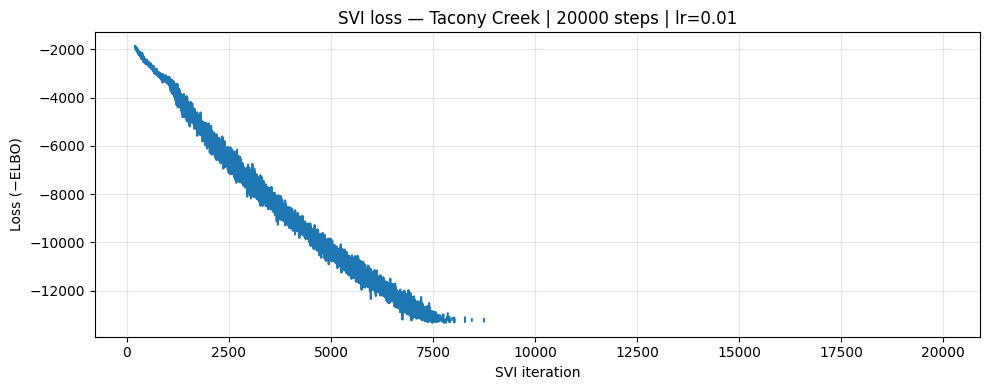

Key trigger posterior means:
  alpha=0.734871
  beta=0.224348
  gamma=0.305119
  sigmax_2=9.83342e-18


C:\Users\Terhi\dev\BSTPP_preview\batch_park_fits.py:670: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  "origin": "lower",


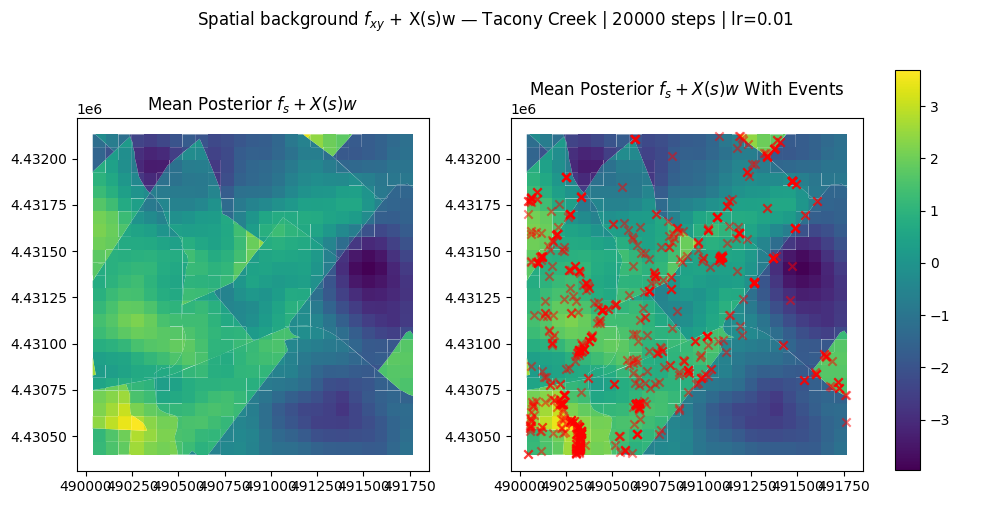

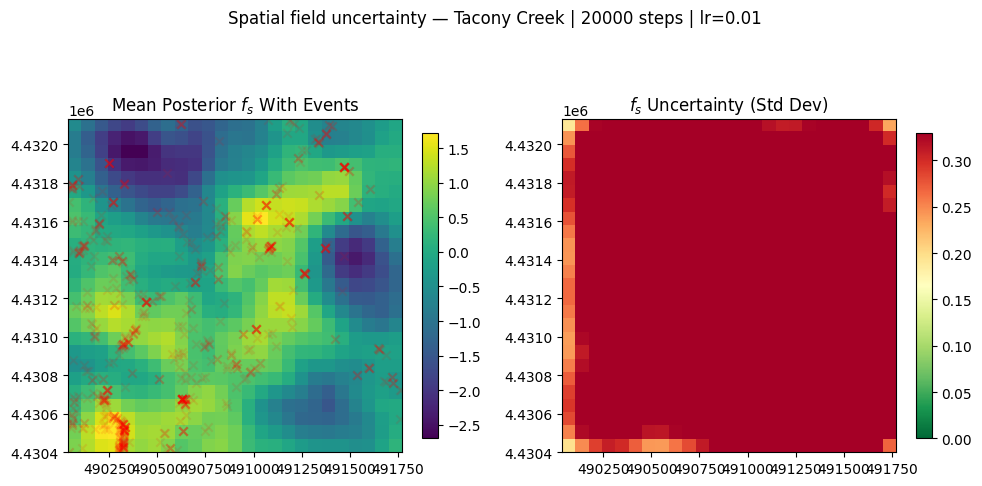

[14:26:59] [1/1] Done Tacony Creek (20000 steps) 2.2 min | AIC=-27048
[14:27:01] Finished 2.2 min — all 1 OK → output\batch_fits\20260810_142432\fit_summary.csv


,run_dir,run_started_at,park_name,park_label,num_steps,lr,window,spatial_window,spatial_sigma_prior_scale_m,num_samples,...,prop_excitation_mean,log_expected_likelihood,expected_aic,final_loss,any_nan_loss,params_txt,trigger_alpha_mean,trigger_beta_mean,trigger_gamma_mean,trigger_sigmax_2_mean
0,C:\Users\Terhi\dev\BSTPP_analysis\output\batch...,2026-08-10T14:24:32,tacony_box,Tacony Creek,20000,0.01,6.160164,500.0,250.0,750,...,0.378333,13807.938477,-27048.138672,NaN,True,C:\Users\Terhi\dev\BSTPP_analysis\output\batch...,0.734871,0.224348,0.305119,9.833420e-18


In [ ]:
import importlib
import batch_park_fits

importlib.reload(batch_park_fits)
from batch_park_fits import (
    run_all_park_fits,
    DEFAULT_FIT_KWARGS,
    PARK_FIT_OVERRIDES,
    build_batch_jobs,
)

# Requires cells above: illegal_dumping_in_park, all_boxes_gdf, cov_gdf, total_days
# Defaults: window=100, num_samples=750; Fairmount override: window=75, num_samples=500
print("Defaults:", DEFAULT_FIT_KWARGS)
print("Overrides:", PARK_FIT_OVERRIDES)
# print("Planned jobs:", build_batch_jobs(
#     ["tacony_box", "cobbscreek_box", "mifflin_box", "fairmount_box"],
#     [6000, 10000],
#     park_num_steps={"mifflin_box": 6000, "fairmount_box": 10000},
#     park_overrides=PARK_FIT_OVERRIDES,
# ))

batch_summary = run_all_park_fits(
    illegal_dumping_in_park=illegal_dumping_in_park,
    all_boxes_gdf=all_boxes_gdf,
    cov_gdf=cov_gdf,
    total_days=total_days,
    output_dir="output/batch_fits",
    park_names=["tacony_box"], # "cobbscreek_box", "mifflin_box", "fairmount_box"],
    num_steps_list=[20000],  # default for parks omitted from park_num_steps
    park_num_steps={
        "mifflin_box": [2000, 6000],
        # "tacony_box": [4000, 10000]
        # tacony, fairmount & cobbscreek use num_steps_list
    },
    # PRE-S3 MIGRATION EDIT: record the provisional prior choice explicitly.
    default_fit_kwargs={
        "spatial_sigma_prior_scale_m": 250.0,
        "temporal_cutoff_days": 180.0, 
        "spatial_window": 500.0,
    },
    lr=0.01,
)
batch_summary

## Model fitting

In [31]:
## PRE-S3 MIGRATION EDIT: Cox-Hawkes analysis configuration

# a_0 = baseline log-intensity
# alpha = magnitute of excitation
# bate = temporal decay rate
# sigmax_2 = spatial decay scale
column_names = ['pop_density', 'med_inc_avg','lep_density','edu_hs_avg','ndvi_mean_4yr'
                ,'RLD', 'RMD','RHD','use_com', 'use_civ','I', 'T', 'GW',
                'vac_area','landcare_area',
                'alloc_avg_d_cnt','alloc_avg_s_cnt','unique_device_ratio_aw','reporting_rate',
                'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d','pagerank_avg_d']

# Preserve the old package behavior exactly: calculate unweighted population
# moments over every supplied CBG row before the model clips to the park.
cov_values = cov_gdf[column_names].to_numpy(dtype=float)
if not np.isfinite(cov_values).all():
    raise ValueError('Legacy standardization requires finite covariate values')
cov_reference_mean = cov_values.mean(axis=0)
cov_reference_scale = cov_values.var(axis=0) ** 0.5
if np.any(cov_reference_scale <= 0.0):
    bad = [column_names[i] for i in np.flatnonzero(cov_reference_scale <= 0.0)]
    raise ValueError(f'Legacy standardization has zero-scale columns: {bad}')
cov_gdf_model = cov_gdf.copy()
cov_gdf_model.loc[:, column_names] = (cov_values - cov_reference_mean) / cov_reference_scale
standardization_record = pd.DataFrame({
    'column': column_names,
    'mean': cov_reference_mean,
    'scale': cov_reference_scale,
})
print(f'Legacy reference rows: {len(cov_gdf_model):,}')

# Spatial quantities are real metric units (EPSG:26918). The cutoff is a
# per-axis square. The prior scale is provisional; rerun with each listed
# sensitivity value before interpreting the spatial trigger.
SPATIAL_WINDOW_M = 1_000.0
SPATIAL_SIGMA_SENSITIVITY_M = (50.0, 100.0, 250.0)
SPATIAL_SIGMA_PRIOR_SCALE_M = 250.0

model = bstpp.main.Hawkes_Model(
    locs_s,     # spatiotemporal points
    #univ_square_gdf,
    all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], # philly boundaries
    total_days, # Time frame
    cox_background=True,
    spatial_cov = cov_gdf_model,# externally standardized spatial covariates
    cov_names = column_names,#columns to use from covariates
    standardize_cov = None,# already standardized over all 1,338 rows
    data_contracts = 'report',# warn/export coverage gaps; preserve old zero-valued behavior
    excitation_support = 'rectangle',# preserve historical bounding-box excitation support
    a_0      = dist.Normal(0,2),
    alpha    = dist.Beta(2,2),
    #beta     = dist.HalfNormal(1.0),
    beta     = dist.Exponential(1.0),
    gamma    = dist.Exponential(1.0),
    sigmax_2 = dist.HalfNormal(SPATIAL_SIGMA_PRIOR_SCALE_M ** 2),
    offset_seasonal = offset_seasonal,
    temporal_trig = bstpp.trigger.Temporal_Power_Law
)

Legacy reference rows: 1,338


100%|██████████| 2000/2000 [00:22<00:00, 89.25it/s, init loss: -1092.0608, avg. loss [1901-2000]: -3490.7694] 


Number of posterior samples: 500
Number of pairs: 201449

SVI elapsed time: 27.781365633010864


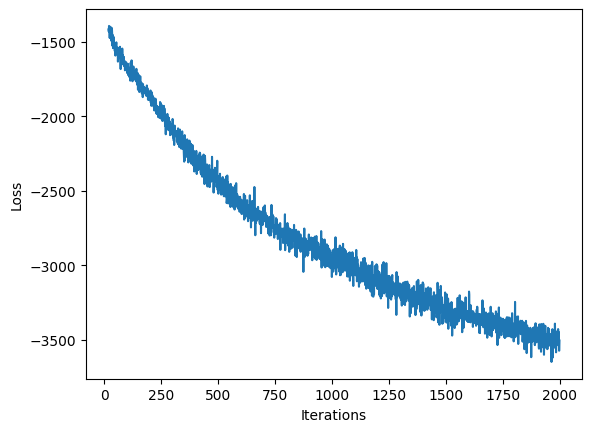

In [32]:
# PRE-S3 MIGRATION EDIT: 1,000 m per-axis computational cutoff.
model.set_window(window=100, spatial_window=SPATIAL_WINDOW_M)

# less interations and bigger learning rate
model.run_svi(lr=0.01,num_steps=2000, num_samples=500)
#model.run_svi(lr=0.03,num_steps=10000)
# ~3 min for 10000 steps

In [ ]:
# model.set_window(window=100, spatial_window=SPATIAL_WINDOW_M)

# # less interations and bigger learning rate
# model.run_svi(lr=0.005,num_steps=6000)
# #model.run_svi(lr=0.03,num_steps=10000)
# # ~3 min for 10000 steps

Length: 2000
Any NaN? False
First NaN at: none
Last valid loss: -3504.975
any inf: False


C:\Users\Terhi\AppData\Local\Temp\ipykernel_22264\3334896436.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


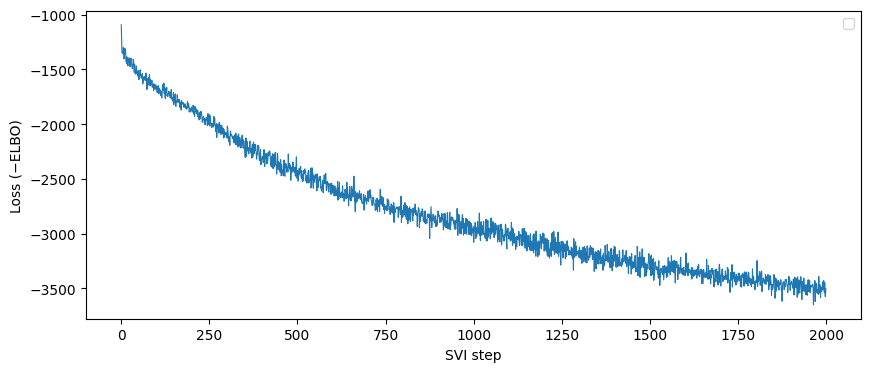

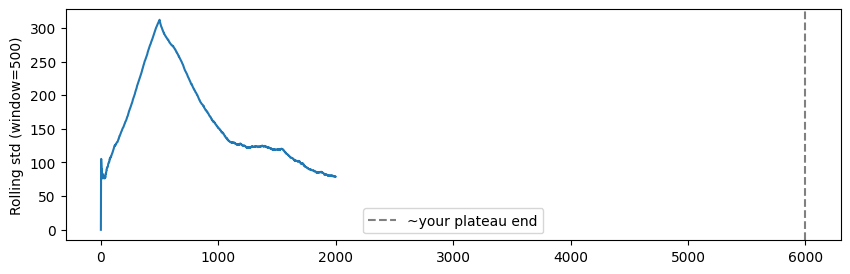

In [33]:
loss = np.asarray(model.svi_results.losses)
print("Length:", len(loss))
print("Any NaN?", np.isnan(loss).any())
print("First NaN at:", np.where(np.isnan(loss))[0][:5] if np.isnan(loss).any() else "none")
print("Last valid loss:", loss[~np.isnan(loss)][-1] if (~np.isnan(loss)).any() else "all NaN")
print("any inf:", np.isinf(loss).any())

# full curve — no 1% trim, mark NaNs
plt.figure(figsize=(10, 4))
plt.plot(loss, lw=0.8)
if np.isnan(loss).any():
    i = int(np.where(np.isnan(loss))[0][0])
    plt.axvline(i, color="r", ls="--", label=f"first NaN @ {i}")
plt.xlabel("SVI step")
plt.ylabel("Loss (−ELBO)")
plt.legend()
plt.show()

# rolling volatility (helps find the “cliff”)
w = 500
roll_std = np.array([np.nanstd(loss[max(0,k-w):k+1]) for k in range(len(loss))])
plt.figure(figsize=(10, 3))
plt.plot(roll_std)
plt.axvline(6000, color="gray", ls="--", label="~your plateau end")
plt.ylabel(f"Rolling std (window={w})")
plt.legend()
plt.show()

In [34]:
for k in ["alpha", "loglik", "a_0"]:
    if k in model.samples:
        x = np.asarray(model.samples[k])
        print(k, "finite:", np.isfinite(x).all(), "  mean:", np.nanmean(x))

alpha finite: True   mean: 0.86606485
loglik finite: True   mean: 3616.3354
a_0 finite: True   mean: -0.30253962


## Results

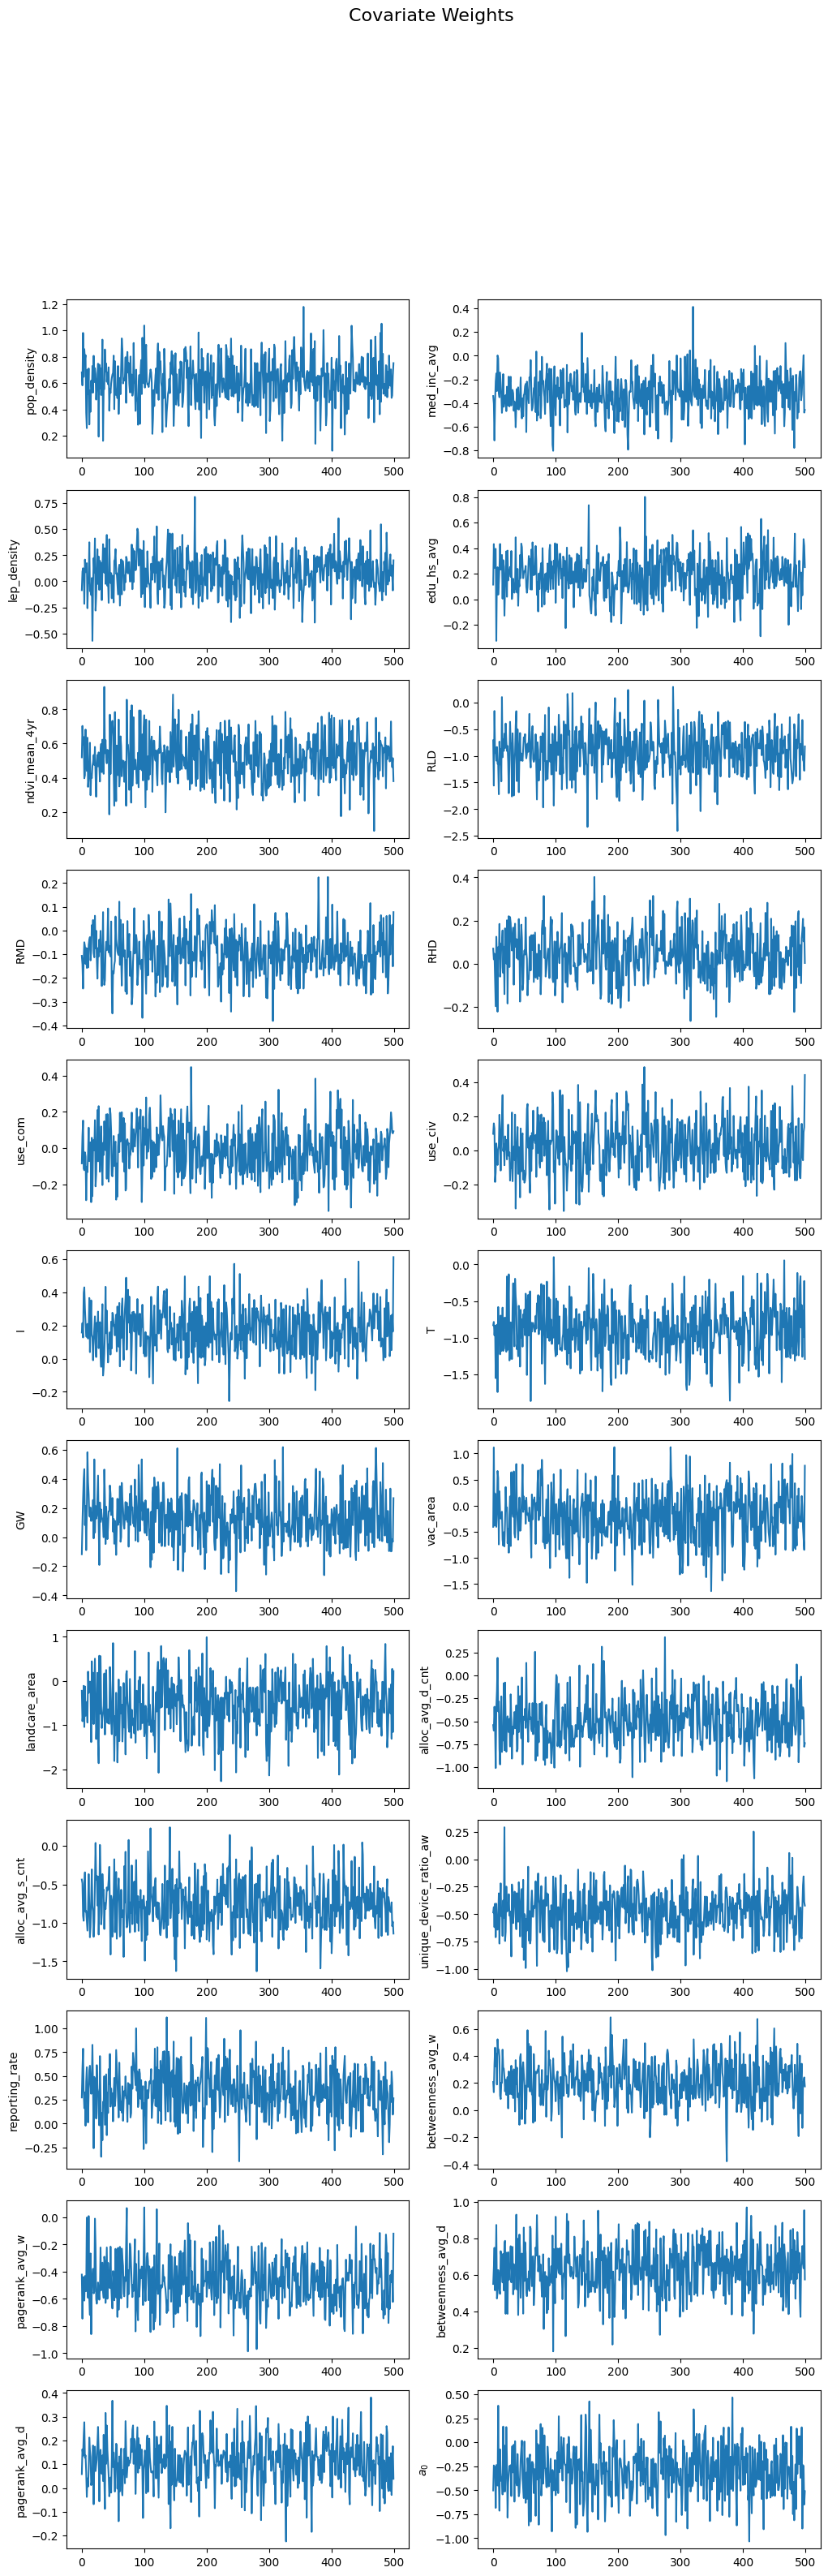

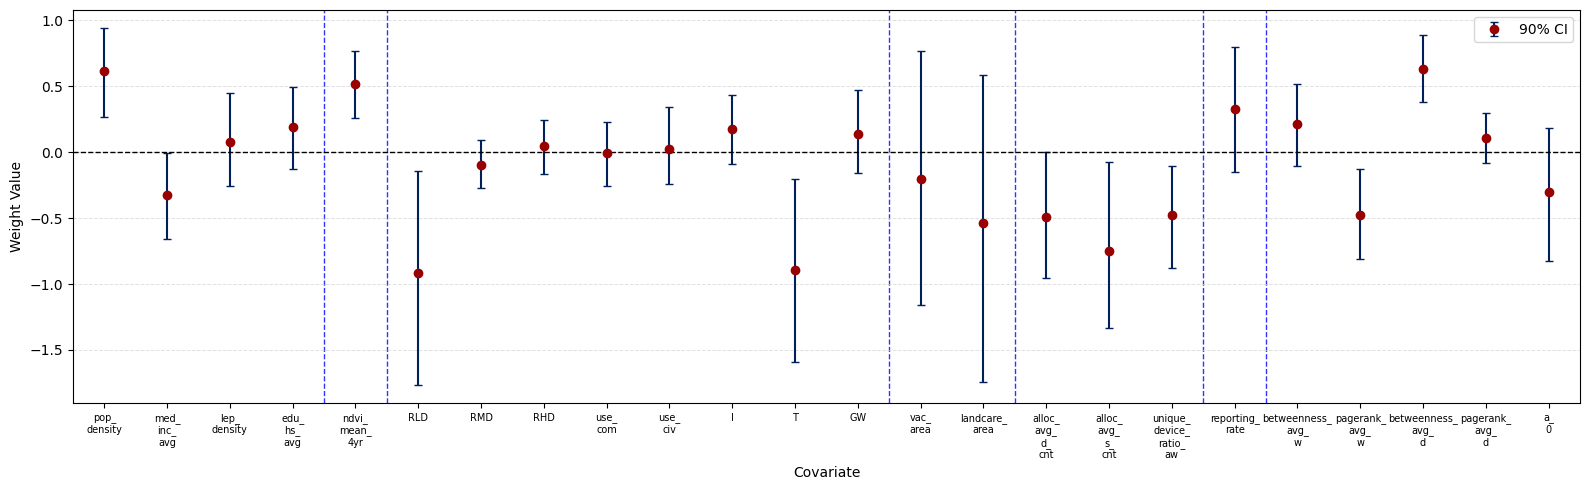

,Post Mean,Post Std,P(w>0),[0.025,0.975]
pop_density,0.618092,0.167845,1.000,0.262509,0.941641
med_inc_avg,-0.321933,0.161179,0.022,-0.656162,-0.008527
lep_density,0.080280,0.184581,0.662,-0.256492,0.444775
edu_hs_avg,0.189849,0.161463,0.876,-0.126709,0.491703
ndvi_mean_4yr,0.516165,0.134259,1.000,0.257656,0.769620
RLD,-0.915092,0.414266,0.018,-1.767804,-0.146717
RMD,-0.097486,0.094006,0.144,-0.275568,0.088648
RHD,0.045312,0.109222,0.664,-0.168437,0.244925
use_com,-0.009715,0.131359,0.480,-0.257788,0.231131
use_civ,0.024123,0.149577,0.560,-0.238788,0.341682


In [35]:
model.cov_weight_post_summary(trace=True)

- Higher values indicate better model fit to the data

In [36]:
model.log_expected_likelihood(locs_s)

3765.933837890625

In [ ]:
model.expected_AIC()

In [ ]:
model.plot_prop_excitation()


In [ ]:
par_names = model.args['t_trig'].get_par_names()
print(par_names)

In [ ]:
model.plot_trigger_posterior(trace=False)

MAPS HERE

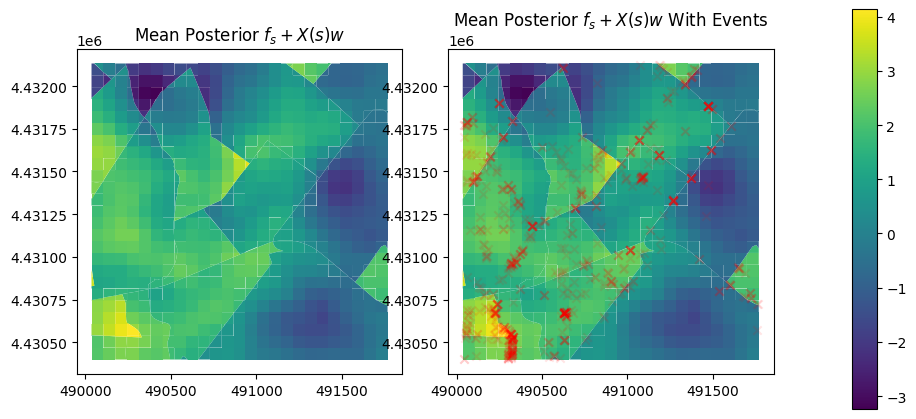

In [46]:
model.plot_spatial(include_cov=True)


In [47]:
# ## Spatial trigger ------------------------------------------------------
# # Step 1: Draw the original plot
# model.plot_spatial(include_cov=True)

# # Step 2: Grab the existing figure and axes
# fig = plt.gcf()
# axs = fig.get_axes()  # Usually [ax0, ax1, colorbar_ax]

# # Match limits from left subplot
# xlim = axs[0].get_xlim()
# ylim = axs[0].get_ylim()

# #philly_border.plot(ax=axs[0], edgecolor='red', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[0], edgecolor='white', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)

# # Add overlays
# #all_boxes_gdf.plot(ax=axs[1], edgecolor='blue', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[1], edgecolor='darkgray', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[1], edgecolor='white', facecolor='none', linewidth=2)


# # Set the same limits on the right subplot
# axs[1].set_xlim(xlim)
# axs[1].set_ylim(ylim)

# # Step 3: Add a new axis to the right
# osm_ax = fig.add_axes([1, 0.1, 0.3, 0.8])  # [left, bottom, width, height]

# # Step 4: Draw the OpenStreetMap on the new axis
# osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
# philly_2023_3857 = philly_2023.to_crs(epsg=3857)
# all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
# land_use_current = land_use_current.to_crs(epsg=3857)
# land_care_21_25 = land_care_21_25.to_crs(epsg=3857)
# vacant_block = vacant_block.to_crs(epsg = 3857)

# # plot cbg and park boundary
# philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3)
# all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='black', linewidth=1, zorder=2)
# osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)
# land_care_21_25.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='#00ffff', alpha=0.7,linewidth=1,zorder=4)
# vacant_block.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='gray', alpha=0.7,linewidth=1, zorder=4)

# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=osm_ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.8,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )

# # Zoom to selected park
# xlim = osm_box.total_bounds[[0, 2]]
# ylim = osm_box.total_bounds[[1, 3]]
# osm_ax.set_xlim(xlim)
# osm_ax.set_ylim(ylim)

# ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
# #ctx.add_basemap(osm_ax)


# # Add the scale bar in kilometers
# scalebar = ScaleBar(
#     dx=1,  # 1 pixel = 1 meter (Web Mercator)
#     units='m',  # use kilometers
#     dimension='si-length',
#     length_fraction=0.25,
#     location='lower right',
#     scale_loc='bottom',
#     box_color='white',
#     box_alpha=0.8,
#     border_pad=0.6,
#     color='black',
#     font_properties={'size': 10}
# )
# osm_ax.add_artist(scalebar)

# # Optional: Clean up
# osm_ax.set_title("OpenStreetMap View")
# osm_ax.set_axis_off()

# # plt.savefig('output/spatial_trigger_mifflin_zoning_full.png', dpi=500, bbox_inches='tight')
# # ~5 min

In [49]:
# ## Spatial trigger ------------------------------------------------------
# # Step 1: Draw the original plot
# model.plot_spatial(include_cov=False)

# # Step 2: Grab the existing figure and axes
# fig = plt.gcf()
# axs = fig.get_axes()  # Usually [ax0, ax1, colorbar_ax]

# # Match limits from left subplot
# xlim = axs[0].get_xlim()
# ylim = axs[0].get_ylim()

# #philly_border.plot(ax=axs[0], edgecolor='red', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[0], edgecolor='white', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)

# # Add overlays
# #all_boxes_gdf.plot(ax=axs[1], edgecolor='blue', facecolor='none', linewidth=2)
# philly_border.plot(ax=axs[1], edgecolor='darkgray', facecolor='none', linewidth=2)
# all_parks_gdf.plot(ax=axs[1], edgecolor='white', facecolor='none', linewidth=2)


# # Set the same limits on the right subplot
# axs[1].set_xlim(xlim)
# axs[1].set_ylim(ylim)

# # Step 3: Add a new axis to the right
# osm_ax = fig.add_axes([1, 0.1, 0.3, 0.8])  # [left, bottom, width, height]

# # Step 4: Draw the OpenStreetMap on the new axis
# osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
# philly_2023_3857 = philly_2023.to_crs(epsg=3857)
# all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
# land_use_current = land_use_current.to_crs(epsg=3857)
# land_care_21_25 = land_care_21_25.to_crs(epsg=3857)
# vacant_block = vacant_block.to_crs(epsg = 3857)

# # plot cbg and park boundary
# philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3)
# all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='black', linewidth=1, zorder=2)
# osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)
# #land_care_21_25.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='#00ffff', alpha=0.7,linewidth=1,zorder=4)
# #vacant_block.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='gray', alpha=0.7,linewidth=1, zorder=4)

# ## plot land use type
# land_use_current['type'] = land_use_current['type'].astype('category')
# #cmap = 'tab20b' # set qualitatitive color map
# cmap = ListedColormap(use_color)

# land_use_current[land_use_current['year'] == 2023].plot(
#     ax=osm_ax,
#     column='type',
#     cmap=cmap,
#     alpha=0.8,
#     legend=True,
#     legend_kwds={
#         'loc': 'center left',
#         'bbox_to_anchor': (1, 0.5),
#         'title': 'Land Use Type'
#     }
# )

# # Zoom to selected park
# xlim = osm_box.total_bounds[[0, 2]]
# ylim = osm_box.total_bounds[[1, 3]]
# osm_ax.set_xlim(xlim)
# osm_ax.set_ylim(ylim)

# ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
# #ctx.add_basemap(osm_ax)


# # Add the scale bar in kilometers
# scalebar = ScaleBar(
#     dx=1,  # 1 pixel = 1 meter (Web Mercator)
#     units='m',  # use kilometers
#     dimension='si-length',
#     length_fraction=0.25,
#     location='lower right',
#     scale_loc='bottom',
#     box_color='white',
#     box_alpha=0.8,
#     border_pad=0.6,
#     color='black',
#     font_properties={'size': 10}
# )
# osm_ax.add_artist(scalebar)

# # Optional: Clean up
# osm_ax.set_title("OpenStreetMap View")
# osm_ax.set_axis_off()

# # plt.savefig('output/spatial_trigger_mifflin_zoning_full.png', dpi=500, bbox_inches='tight')
# # ~5 min

Grid size: 25x25


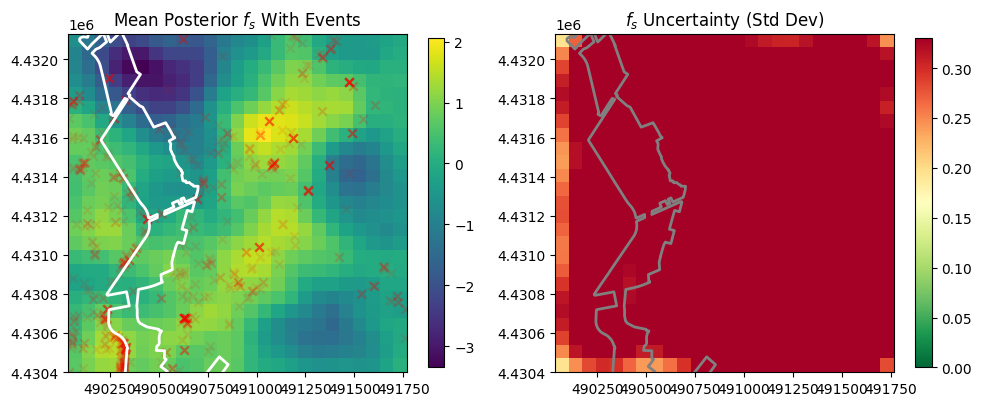

Mean f_xy range: -3.343 to 2.051
Std f_xy range: 0.194 to 0.734


In [50]:
## Uncertainty map ------------------------------------------------------
# Get uncertainty measures
f_xy_samples = model.samples["f_xy"]
f_xy_mean = np.mean(f_xy_samples, axis=0)
f_xy_std = np.std(f_xy_samples, axis=0) # Standard deviation across samples

# Get boundary from model.A geometry
bounds = model.A[['geometry']].total_bounds  # [minx, miny, maxx, maxy]
minx, miny, maxx, maxy = bounds

# Since spatial_grid contains indices, we need to create coordinates
# For a 625-cell grid, this is likely a 25x25 grid (25² = 625)
grid_size = int(np.sqrt(625))  # Should be 25
print(f"Grid size: {grid_size}x{grid_size}")

# Create coordinate arrays based on actual geometry bounds
x_indices = np.linspace(minx, maxx, grid_size)
y_indices = np.linspace(miny, maxy, grid_size)
X, Y = np.meshgrid(x_indices, y_indices)

# Reshape your data to match the grid
f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Mean surface
im1 = ax1.imshow(f_xy_mean_grid, origin='lower', cmap='viridis', extent=[minx, maxx, miny, maxy])
model.points.plot(ax=ax1,color='red',marker='x',alpha=0.1)
all_parks_gdf.plot(ax=ax1, edgecolor='white', facecolor='none', linewidth=2)

ax1.set_title('Mean Posterior $f_s$ With Events')
ax1.set_xlim(minx, maxx)  # Set x limits to bounds
ax1.set_ylim(miny, maxy)  # Set y limits to bounds
plt.colorbar(im1, ax=ax1, shrink=0.7)

# Uncertainty surface
im2 = ax2.imshow(f_xy_std_grid, origin='lower', cmap='RdYlGn_r', extent=[minx, maxx, miny, maxy], vmin=0, vmax=0.33)
all_parks_gdf.plot(ax=ax2, edgecolor='gray', facecolor='none', linewidth=2)

ax2.set_title('$f_s$ Uncertainty (Std Dev)')
ax2.set_xlim(minx, maxx)  # Set x limits to bounds
ax2.set_ylim(miny, maxy)  # Set y limits to bounds
plt.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()
# plt.savefig('output/uncertainty_mifflin.png', dpi=500, bbox_inches='tight')
plt.show()

# Print some summary statistics
print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")

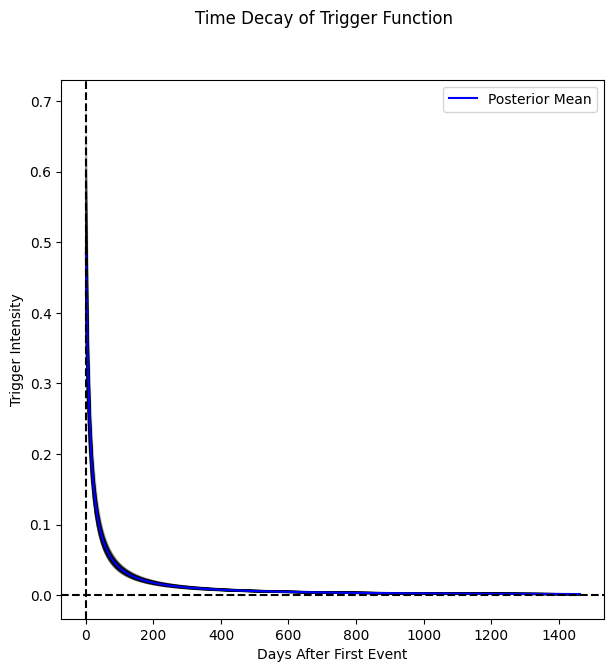

In [51]:
model.plot_trigger_time_decay()

In [ ]:
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)


# fig,ax = plt.subplots(figsize=(9,9))

# # Use the hist() function to plot the frequency distribution of delta_t
# ax.hist(df['delta_t_days'], bins=50, edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests')
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# #plt.tight_layout()
# plt.savefig('output/decay_mifflin_full.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved

In [ ]:
# ## Delta t distribution ------------------------------------------------------
# df = park_points.copy()

# # Ensure the 'start_time' column is in datetime format
# df['start_time'] = pd.to_datetime(df['start_time'])

# # Sort the DataFrame by 'address' and 'start_time'
# df.sort_values(by=['address', 'start_time'], inplace=True)

# # Group by address and get the next start time
# grouped = df.groupby('address')
# df['next_start_time'] = grouped['start_time'].shift(-1)

# # Calculate the time difference in days
# df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# # Drop rows where the next start time is missing
# df.dropna(subset=['delta_t_days'], inplace=True)

# # Create manual bins
# min_val = df['delta_t_days'].min()
# max_val = df['delta_t_days'].max()
# bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2

# # Print binning information
# num_bins = len(bins) - 1
# bin_width = (max_val - min_val) / num_bins
# actual_time_range = max_val - min_val

# print(f"Number of bins: {num_bins}")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# # Calculate histogram manually
# counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # Create the plot
# fig, ax = plt.subplots(figsize=(9,9))

# # Use bar plot instead of hist
# ax.bar(bin_centers, counts, width=np.diff(bins), edgecolor='black', alpha=0.7, color='gray')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests',pad=30)
# ax.set_xlim(-50, 1500)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency')
# ax.grid(axis='y', alpha=0.75)
# plt.tight_layout()
# #plt.savefig('output/delta_t_mifflin.png', dpi=500, bbox_inches='tight')
# plt.show() # This will now show the figure after it has been saved

In [52]:
# Get parameter names
par_names = model.args['t_trig'].get_par_names()  # ['beta', 'gamma']
params_mean = {}

# Calculate mean of posterior samples for each parameter
for name in par_names:
    params_mean[name] = model.samples[name].mean().item()

prior_value = locs_s
tpl = Temporal_Power_Law(prior_value)

# # # Step 2: Use your extracted parameters (replace params_mean with your actual variable)
# # params_from_model = params_mean  # <-- Replace this with your actual parameter variable
# params_from_model = {
#     'beta': float(params_mean['beta']),   # Convert array to scalar
#     'gamma': float(params_mean['gamma'])  # Convert array to scalar
# }

In [53]:
## Delta t distribution ------------------------------------------------------
df = park_points.copy()

# Ensure the 'start_time' column is in datetime format
df['start_time'] = pd.to_datetime(df['start_time'])

# Sort the DataFrame by 'address' and 'start_time'
df.sort_values(by=['address', 'start_time'], inplace=True)

# Group by address and get the next start time
grouped = df.groupby('address')
df['next_start_time'] = grouped['start_time'].shift(-1)

# Calculate the time difference in days
df['delta_t_days'] = (df['next_start_time'] - df['start_time']).dt.total_seconds() / (60 * 60 * 24)

# Drop rows where the next start time is missing
df.dropna(subset=['delta_t_days'], inplace=True)

# Create manual bins
min_val = df['delta_t_days'].min()
max_val = df['delta_t_days'].max()
bins = np.linspace(min_val, max_val, 1200)  # 51 edges create 50 bins
bin_centers_real = (bins[:-1] + bins[1:]) / 2

# Print binning information
num_bins = len(bins) - 1
bin_width = (max_val - min_val) / num_bins
actual_time_range = max_val - min_val

print(f"Number of bins: {num_bins}")
print(f"Bin width: {bin_width:.4f} days")
print(f"Actual time range: {actual_time_range:.4f} days (from {min_val:.4f} to {max_val:.4f})")

# Calculate histogram manually
counts, _ = np.histogram(df['delta_t_days'], bins=bins)

# # simulated delta t------------------------------------------------------------
# # set the scale for rescalring
# scale = total_days / 50  # e.g., 1460/50

# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200

# max_time = 365 * 4  # days
# num_bins = int(max_time / bin_width)
# bin_edges = np.linspace(0, max_time, num_bins + 1) 

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         s = tpl.simulate_trigger(params_from_model)  # already in days
#         s_days = s * scale
#         samples.append(s_days)             # clip to match bins
#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)
#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# histogram_matrix = np.array(histogram_matrix)

# column_averages = np.mean(histogram_matrix, axis=0)

# fig, ax = plt.subplots(figsize=(9,9))

# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

Number of bins: 1199
Bin width: 1.0593 days
Actual time range: 1270.0611 days (from 0.0000 to 1270.0611)


In [ ]:
# fig, ax = plt.subplots(figsize=(9,9))

# # First dataset - observed data (1199 points)
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Second dataset - simulated data (1518 points) - separate plot call
# ax.plot(bin_centers, column_averages, marker='s', linestyle='-', 
#         color='#4d5aaf', linewidth=1.5, markersize=2, label='Simulated')

# # Set labels and title
# ax.set_title('Frequency Distribution of Time Difference Between Requests', pad=30)
# ax.set_xlabel('Time Difference (days)')
# ax.set_ylabel('Frequency / Count')
# ax.set_xlim(-10, 200)
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# # plt.savefig('output/delta_t_tacony_simulated.png', dpi=500, bbox_inches='tight')
# plt.show()

C:\Users\Terhi\AppData\Local\Temp\ipykernel_22264\1883419747.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


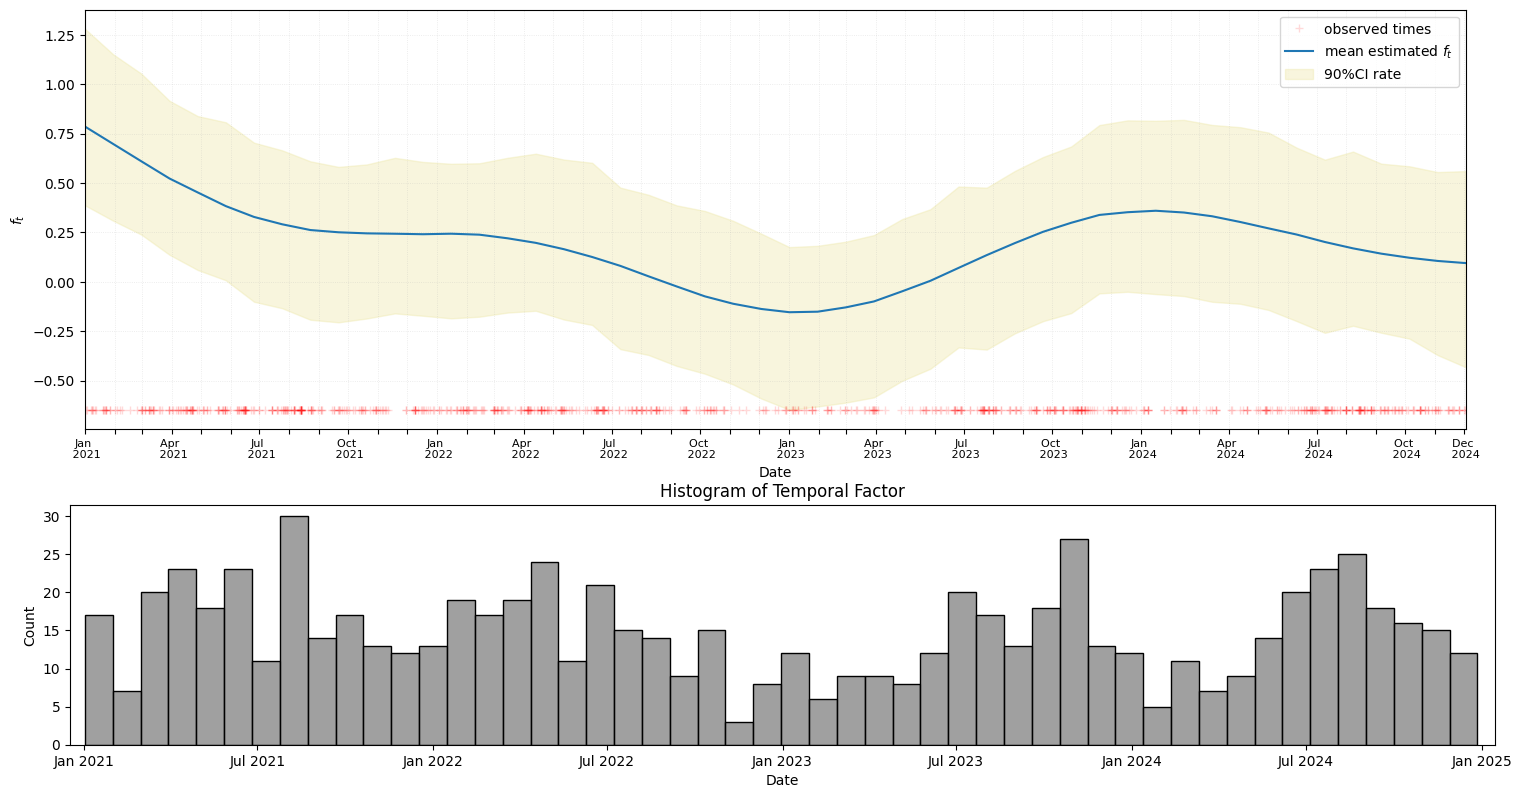

In [54]:
model.plot_temporal(start_date=min_time)

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()

# Plot histogram on ax2
hist_ax = fig.add_axes([0.05, -0.5, 0.95, 0.48])  # [left, bottom, width, height]

sns.histplot(park_points['start_time'], bins=50, kde=False, ax=hist_ax, color='gray')
hist_ax.set_xlabel("Date")
hist_ax.set_ylabel("Count")
hist_ax.set_title("Histogram of Temporal Factor")
start = pd.to_datetime("2021-01-01") - pd.Timedelta(days=15)
end = pd.to_datetime("2024-12-31") + pd.Timedelta(days=15)
hist_ax.set_xlim(start, end)
#hist_ax.xaxis.set_major_locator(plt.MaxNLocator(10))
hist_ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))


plt.tight_layout()
#plt.savefig('output/temp_mifflin_full.png', dpi=500, bbox_inches='tight')
plt.show()

In [55]:
def simulate_triggers_histogram(beta, gamma, df, locs_s, tpl, scale, 
                                max_time=365*4, num_bins=1200, n_iterations=500):
    """
    Simulate trigger times and generate histogram for given beta and gamma parameters.
    """
    # First calculate the bin width from your data
    data_min = df['delta_t_days'].min()
    data_max = df['delta_t_days'].max()
    data_range = data_max - data_min
    bin_width = data_range / num_bins
    
    # Create bin edges
    num_bins_calc = int(max_time / bin_width)
    bin_edges = np.linspace(0, max_time, num_bins_calc + 1)
    
    # Set up parameters
    params_from_model = {
        'beta': float(beta),
        'gamma': float(gamma)
    }
    
    histogram_matrix = []
    
    for i in range(n_iterations):
        samples = []
        for j in range(locs_s.shape[0]):
            s = tpl.simulate_trigger(params_from_model)
            s_days = s * scale
            samples.append(s_days)
        
        hist_counts, _ = np.histogram(samples, bins=bin_edges)
        histogram_matrix.append(hist_counts)
    
    histogram_matrix = np.array(histogram_matrix)
    column_averages = np.mean(histogram_matrix, axis=0)
    
    return bin_edges, column_averages


def run_posterior_simulations(model, df, locs_s, tpl, scale, 
                              n_posterior_samples=100, **kwargs):
    """
    Run simulations using posterior samples of beta and gamma.
    """
    # Extract parameter names
    par_names = model.args['t_trig'].get_par_names()
    
    # Get total number of posterior samples
    n_samples = len(model.samples[par_names[0]])
    
    # Randomly sample indices
    indices = np.random.choice(n_samples, size=n_posterior_samples, replace=False) # 
    
    all_histograms = []
    
    print(f"\n{'='*70}")
    print(f"Starting posterior simulations with {n_posterior_samples} parameter samples")
    print(f"{'='*70}\n")
    
    # Use tqdm.notebook for Jupyter - it has a nice widget-based progress bar
    pbar = tqdm(total=n_posterior_samples, desc="Overall Progress")
    
    for idx, i in enumerate(indices):
        # Extract beta and gamma for this iteration
        beta = float(model.samples['beta'][i])
        gamma = float(model.samples['gamma'][i])
        
        # Print posterior sample info
        print(f"Posterior sample {idx + 1}/{n_posterior_samples}: beta={beta:.4f}, gamma={gamma:.4f}")
        
        # Run simulation with these parameters
        bin_edges, column_avg = simulate_triggers_histogram(
            beta, gamma, df, locs_s, tpl, scale,
            **kwargs
        )
        
        all_histograms.append(column_avg)
        
        # Update progress bar
        pbar.update(1)
    
    pbar.close()
    
    print(f"\n{'='*70}")
    print("✓ All posterior simulations completed!")
    print(f"{'='*70}\n")
    
    # Convert to array and calculate statistics
    all_histograms = np.array(all_histograms)
    
    print("Calculating statistics across all posterior samples...")
    mean_counts = np.mean(all_histograms, axis=0)
    lower_bound = np.percentile(all_histograms, 2.5, axis=0)
    upper_bound = np.percentile(all_histograms, 97.5, axis=0)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    
    return bin_centers, mean_counts, lower_bound, upper_bound, all_histograms

In [ ]:
# # Usage:
# scale = total_days / 50  # Your existing scale

# # Run with posterior uncertainty
# bin_centers, mean_counts, lower_bound, upper_bound, all_histograms = run_posterior_simulations(
#     model=model,
#     df=df,
#     locs_s=locs_s,
#     tpl=tpl,
#     scale=scale,
#     n_posterior_samples=100,  # Adjust based on computational budget
#     max_time=365*4,
#     num_bins=1200,
#     n_iterations=500
# )

# # Plot results
# fig, ax = plt.subplots(figsize=(12, 8))

# # plot observed data
# ax.plot(bin_centers_real, counts, marker='o', linestyle='-', 
#         color='#69821b', linewidth=1.5, markersize=2, label='Observed',alpha=0.7)

# # Plot mean line
# ax.plot(bin_centers, mean_counts, color='blue', linewidth=1, label='Simulated (Mean)')

# # Plot uncertainty band
# ax.fill_between(bin_centers, lower_bound, upper_bound, 
#                 color='#4d5aaf', alpha=0.3, label='95% Confidence Interval')

# # If you have observed data, plot it too
# # ax.bar(observed_bins, observed_counts, alpha=0.7, color='green', 
# #        label='Observed', width=bin_width*0.8)

# ax.set_xlabel('Time Difference (days)', fontsize=12)
# ax.set_ylabel('Count', fontsize=12)
# ax.set_title('Trigger Simulation with Posterior Uncertainty', fontsize=14)
# ax.set_xlim(-10, 200)
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig('output/delta_t_tacony_simulated.png', dpi=500, bbox_inches='tight')
# plt.show()

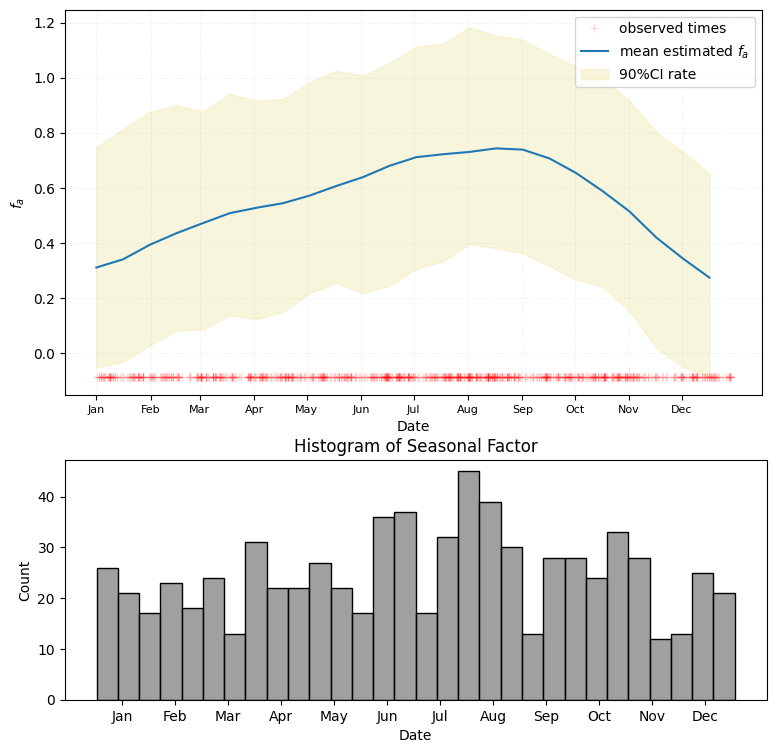

In [56]:
model.plot_seasonal()

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()

# Plot histogram on ax2
hist_ax = fig.add_axes([0.125, -0.5, 0.78, 0.48])  # [left, bottom, width, height]

sns.histplot(locs_s['A'], bins=30, kde=False, ax=hist_ax, color='gray')
hist_ax.set_xlabel("Date")
hist_ax.set_ylabel("Count")
hist_ax.set_title("Histogram of Seasonal Factor")
# Format x-axis as Jan, Feb, etc.
month_locs = [15 + i*30 for i in range(12)]  # rough midpoints for months
month_labels = [calendar.month_abbr[i+1] for i in range(12)]

hist_ax.set_xticks(month_locs)
hist_ax.set_xticklabels(month_labels)
#plt.savefig('output/seasonal_mifflin_full.png', dpi=500, bbox_inches='tight')
plt.show()

In [ ]:
# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200  # From your bins=50 in the histogram

# max_time = 365 * 4  # 4 years in days
# num_bins = int(max_time / bin_width)  # Calculate number of bins based on your bin width
# bin_edges = np.linspace(0, max_time, num_bins + 1)

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# # store histogram for each iteration
# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         sample = tpl.simulate_trigger(params_from_model)
#         samples.append(sample / (24*60*60))

#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)

#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/1000 iterations")

# histogram_matrix = np.array(histogram_matrix)


# print(f"\nHistogram matrix shape: {histogram_matrix.shape}")
# print(f"Rows (iterations): {histogram_matrix.shape[0]}")
# print(f"Columns (time bins): {histogram_matrix.shape[1]}")


# # Calculate column averages (average across iterations for each time bin)
# column_averages = np.mean(histogram_matrix, axis=0)

# # Plot average counts per time bin
# plt.figure(figsize=(6, 6))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# plt.bar(bin_centers, column_averages, width=bin_width*0.8, alpha=0.7, edgecolor='black')
# plt.xlabel('Time (days)')
# plt.ylabel('Average Count')
# plt.xlim(-50, 1500)
# plt.title(f'Average Sample Counts per Time Bin\n({histogram_matrix.shape[0]} iterations, bin width: {bin_width:.1f} days)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nColumn averages statistics:")
# print(f"Mean of bin averages: {np.mean(column_averages):.2f}")
# print(f"Std of bin averages: {np.std(column_averages):.2f}")
# print(f"Expected average per bin: {locs_s.shape[0] / num_bins:.2f}")


In [ ]:
# ## set the scale for rescalring
# scale = total_days / 50  # e.g., 1460/50

# # First calculate the bin width from your data
# data_min = df['delta_t_days'].min()
# data_max = df['delta_t_days'].max()
# data_range = data_max - data_min
# bin_width = data_range / 1200

# max_time = 365 * 4  # days
# num_bins = int(max_time / bin_width)
# bin_edges = np.linspace(0, max_time, num_bins + 1) 

# print(f"Bin width: {bin_width:.1f} days")
# print(f"Number of bins: {num_bins}")
# print(f"Time range: 0 to {max_time} days")

# histogram_matrix = []

# for i in range(500):
#     samples = []
#     for j in range(locs_s.shape[0]):
#         s = tpl.simulate_trigger(params_from_model)  # already in days
#         s_days = s * scale
#         samples.append(s_days)             # clip to match bins
#     hist_counts, _ = np.histogram(samples, bins=bin_edges)
#     histogram_matrix.append(hist_counts)
#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# histogram_matrix = np.array(histogram_matrix)

# column_averages = np.mean(histogram_matrix, axis=0)

# plt.figure(figsize=(6, 6))
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# plt.bar(bin_centers, column_averages, width=np.diff(bin_edges)*0.8, alpha=0.7, edgecolor='black')

# plt.xlabel('Time (days)')
# plt.ylabel('Average Count')
# plt.xlim(-50, 1500)
# #plt.ylim(0, 100)
# plt.title(f'Average Sample Counts per Time Bin\n({histogram_matrix.shape[0]} iterations, bin width: {bin_width:.1f} days)')
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"\nColumn averages statistics:")
# print(f"Mean of bin averages: {np.mean(column_averages):.2f}")
# print(f"Std of bin averages: {np.std(column_averages):.2f}")

In [ ]:
# # Store histogram for each iteration
# samples_matrix = []

# # Do 1500 iterations
# for i in range(500):
#     # Sample locs_s.shape[0] times in this iteration
#     samples = []
#     for j in range(locs_s.shape[0]):
#         sample = tpl.simulate_trigger(params_from_model)
#         samples.append(sample/(24*60*60))  #  convert to days
    
#     # Create histogram for this iteration
#     samples_matrix.append(samples)

#     if (i + 1) % 100 == 0:
#         print(f"Completed {i + 1}/500 iterations")

# # Convert to numpy array: shape will be (500, 50)
# samples_matrix = np.array(samples_matrix)

# print(f"\nHistogram matrix shape: {samples_matrix.shape}")
# print(f"Rows (iterations): {samples_matrix.shape[0]}")
# print(f"Columns (time bins): {samples_matrix.shape[1]}")

In [ ]:
# column_means = np.mean(samples_matrix, axis=0)
# print(f"Shape of column means: {column_means.shape}")
# print(f"First 10 column means: {column_means[:10]}")

# column_means = np.sort(column_means)

# # Step 2: Calculate delta_t between consecutive columns
# # This represents the change in mean values between adjacent time bins
# delta_t_simulated = np.diff(column_means)
# print(f"Shape of delta_t: {delta_t_simulated.shape}")
# print(f"First 10 delta_t values: {delta_t_simulated[:10]}")

# # Step 3: Extract max, min, and range for the delta_t values
# min_delta = np.min(delta_t_simulated)
# max_delta = np.max(delta_t_simulated)
# delta_range = max_delta - min_delta

# print(f"Delta_t statistics:")
# print(f"Min delta_t: {min_delta:.4f}")
# print(f"Max delta_t: {max_delta:.4f}")
# print(f"Range: {delta_range:.4f}")

# # Step 4: Create bin edges for delta_t distribution (50 bins)
# bins = np.linspace(min_delta, max_delta, 51)  # 51 edges create 50 bins
# bin_centers = (bins[:-1] + bins[1:]) / 2
# bin_width = (max_delta - min_delta) / 50

# print(f"Number of bins: 50")
# print(f"Bin width: {bin_width:.4f} days")
# print(f"Actual range: {delta_range:.4f} days (from {min_delta:.4f} to {max_delta:.4f})")

# # Check for problematic values

# print("--------------------------------")
# print("Column means stats:")
# print(f"Min: {np.min(column_means)}")
# print(f"Max: {np.max(column_means)}")
# print(f"Any NaN?: {np.any(np.isnan(column_means))}")
# print(f"Any Inf?: {np.any(np.isinf(column_means))}")

# # Check the original matrix
# print("Samples matrix stats:")
# print(f"Min: {np.min(samples_matrix)}")
# print(f"Max: {np.max(samples_matrix)}")
# print(f"Any NaN?: {np.any(np.isnan(samples_matrix))}")
